# Семинар №3

## <center>Convolutional neural network`</center>

> **What is it?**
>    * a type of artificial neural network where the architecture is such that the incoming data is identified as image and processed with a kernel of specific size
>    * it can be either **`Conv1d`** - for vectors of size (batch, channels, length); **`Conv2d`** - for images of size (batch, channels, height, width) and **`Conv3d`**. 

![image](conv2d_padding.gif)

>   * all of the modules have the following params:
>     * **`in_channels`** - № of imput channels (3 for RGB, 1 for grayscale)
>     * **`out_channels`** - № of output channels, produced by the layer
>     * **`kernel_size`** - size of the kernel, processing the image
>     * **`stride`** - convolution's kernel step between scannings
>     * **`padding`** - size of the padding, number of zeros to extend the image
>     * **`dilation`** - step between kernel's elements within itself
>     * **`bias`** - boolean flag either to add learnable bias or not

### <center> How to train everything? </center>

**1. Libraries**

In [1]:
# === БАЗОВЫЕ БИБЛИОТЕКИ PYTHON ===
import os  # для работы с операционной системой и файловыми путями
import numpy as np  # для работы с многомерными массивами и математических операций
import pandas as pd  # для работы с табличными данными
import matplotlib.pyplot as plt  # для визуализации данных и графиков

# === ОСНОВНЫЕ МОДУЛИ PYTORCH ===
import torch  # основная библиотека PyTorch для работы с тензорами и нейронными сетями
from torch import nn  # модуль с классами слоев нейронных сетей (Linear, Conv2d и др.)

# === РАБОТА С ДАТАСЕТАМИ ===
from torch.utils.data import Dataset  # базовый класс для создания собственных датасетов
from torchvision import datasets  # готовые популярные датасеты (MNIST, CIFAR и др.)
from torchvision.transforms import ToTensor  # преобразование изображений в тензоры PyTorch
from torchvision.io import read_image  # чтение изображений и конвертация в тензоры

# === ЗАГРУЗКА ДАННЫХ ===
from torch.utils.data import DataLoader  # класс для пакетной загрузки данных в модель

# === ФУНКЦИИ АКТИВАЦИИ И ОПЕРАЦИИ ===
import torch.nn.functional as F  # функциональный API с функциями активации, loss-функциями и др.


**2. Dataset**

In [2]:
# Загружаем тренировочный датасет MNIST
train_set = datasets.MNIST(
    root="data",  # путь к папке, где будут храниться/уже хранятся данные
    train=True,  # указываем, что нужна тренировочная часть датасета (60000 изображений)
    download=True,  # автоматически скачать данные из интернета, если их нет в папке root
    transform=ToTensor()  # преобразование: конвертируем изображения из PIL в тензоры PyTorch
)

# Загружаем валидационный (тестовый) датасет MNIST
val_set = datasets.MNIST(
    root="data",  # та же папка с данными
    train=False,  # указываем, что нужна тестовая часть датасета (10000 изображений)
    download=True,  # скачать, если отсутствует
    transform=ToTensor()  # то же преобразование в тензоры
)


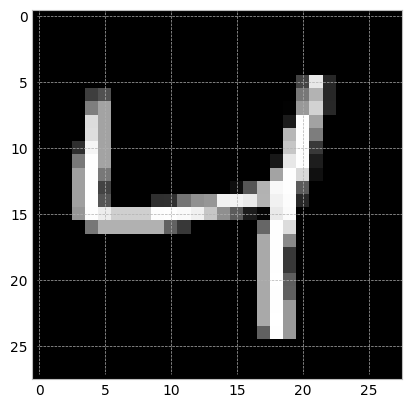

4


In [15]:
# Получаем один пример из тренировочного датасета (индекс 1)
# x - изображение (тензор размера [1, 28, 28]: 1 канал, высота 28, ширина 28)
# y - метка класса (цифра от 0 до 9)
x, y = train_set[2]

# Визуализируем изображение
plt.imshow(
    x[0, :, :],  # берем первый (и единственный) канал изображения [28, 28]
    cmap='gray'  # используем серую цветовую схему (grayscale)
)
plt.show()

# Выводим метку класса (какая цифра на изображении)
print(y)  # результат: 0


**3. Dataloader**

In [4]:
# DataLoader для тренировочных данных
train_loader = DataLoader(
    train_set,  # датасет, из которого будем загружать данные
    batch_size=64,  # размер батча - загружаем по 64 изображения за раз
    shuffle=True  # перемешиваем данные перед каждой эпохой (важно для обучения!)
)

# DataLoader для валидационных данных
val_loader = DataLoader(
    val_set,  # тестовый датасет
    batch_size=64,  # тот же размер батча
    shuffle=False  # НЕ перемешиваем валидационные данные (порядок не важен при оценке)
)


**4. Neural network**

In [27]:
class Animal:

    def __init__(self, name):
        self.name = name

    def say_your_name(self):
        print(self)
        print(f'Меня зовут {self.name}')


dog = Animal('Шарик')
horse = Animal('Пегас')

In [28]:
dog

In [29]:
horse

In [30]:
dog.say_your_name()

# питон вызывает метод say_your_name и сам подставляет аргумент self=dog в метод на первое место
# чтобы внутри метода мы поняли, кто именно этот метод вызвал

Меня зовут Шарик


In [38]:
# Определяем полносвязную нейронную сеть (Multilayer Perceptron)
class MLP(nn.Module):  # наследуемся от базового класса nn.Module
    
    def __init__(self, hidden_size):
        """
        Инициализация архитектуры сети
        
        Args:
            hidden_size: количество нейронов в скрытом слое
        """
        super().__init__()  # вызываем конструктор родительского класса
        
        # Первый полносвязный слой: 784 входа -> hidden_size выходов
        # 784 = 28*28 (размер "развернутого" изображения MNIST)
        self.linear1 = nn.Linear(784, hidden_size)
        self.activation = nn.ReLU()
        
        # Второй полносвязный слой: hidden_size входов -> 10 выходов
        # 10 = количество классов (цифры 0-9)
        self.linear2 = nn.Linear(hidden_size, 10)
    
    def forward(self, x):
        """
        Прямой проход (forward pass) - как данные проходят через сеть
        
        Args:
            x: входной тензор изображений размера (batch_size, 1, 28, 28)
        
        Returns:
            выходной тензор с логитами размера (batch_size, 10)
        """
        #print(f'Размерность ДО выпрямления: {x.shape}')
        # Шаг 1: "Разворачиваем" изображение в одномерный вектор
        # Из (batch_size, 1, 28, 28) получаем (batch_size, 784)
        # start_dim=1 означает: оставляем размер батча, всё остальное объединяем
        x = torch.flatten(x, start_dim=1)
        #print(f'Размерность после выпрямления: {x.shape}')
        
        # Шаг 2: Пропускаем через первый линейный слой
        x = self.linear1(x)  # (batch_size, hidden_size)
        
        # Шаг 3: Применяем функцию активации ReLU (Rectified Linear Unit)
        # ReLU(x) = max(0, x) - заменяет отрицательные значения на 0
        x = self.activation(x)
        
        # Шаг 4: Пропускаем через второй линейный слой (выходной)
        x = self.linear2(x)  # (batch_size, 10) - логиты для каждого класса
        
        return x


In [6]:
import torch

x = torch.randint(0, 100, (8, 32, 4, 4))
torch.flatten(x, 2).shape

torch.Size([8, 32, 16])

In [14]:
from math import exp

output = [1, 0.5, -1]
# предсказание для собаки, кошки и лошади

new_dog = exp(1) / (exp(1) + exp(0.5) + exp(-1))
new_cat  = exp(0.5) / (exp(1) + exp(0.5) + exp(-1))
new_horse  = exp(-1) / (exp(1) + exp(0.5) + exp(-1))

In [15]:
print(f'Собака до: {output[0]}, собака после {new_dog}')
print(f'Кошка до: {output[1]}, собака после {new_cat}')
print(f'Лошадь до: {output[2]}, собака после {new_horse}')

Собака до: 1, собака после 0.5740969929676945
Кошка до: 0.5, собака после 0.3482074278837348
Лошадь до: -1, собака после 0.07769557914857057


In [39]:
# Определяем сверточную нейронную сеть (Convolutional Neural Network)
class ConvNet(nn.Module):
    def __init__(self):
        """
        Инициализация архитектуры CNN
        """
        super().__init__()
        
        # Первый сверточный слой
        # Принимает: 1 канал (grayscale изображение)
        # Выдает: 16 карт признаков (feature maps)
        # Размер ядра свертки: 5x5 пикселей

        # принимает либо три размерности (Channels, Height, Width)
        # либо четыре размерности (Number of img in batch, Channels, Height, Width)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5)
        self.activation = nn.ReLU()
        
        # Второй сверточный слой
        # Принимает: 16 каналов (выход предыдущего слоя)
        # Выдает: 32 карты признаков
        # Размер ядра: 5x5
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5)
        
        # Слой максимального пулинга (MaxPooling)
        # Уменьшает пространственные размеры в 2 раза
        # Берет максимум из окна 2x2
        self.pool = nn.MaxPool2d(kernel_size=2)
        
        # Полносвязный слой (классификатор)
        # 512 входов (32 * 4 * 4 после всех сверток и пулингов) -> 10 классов
        self.fc = nn.Linear(512, 10)
    
    def forward(self, x):
        """
        Прямой проход через сверточную сеть
        
        Args:
            x: входной тензор размера (batch_size, 1, 28, 28)
        
        Returns:
            выходной тензор с логитами размера (batch_size, 10)
        """
        # === ПЕРВЫЙ БЛОК: Conv -> Pool -> ReLU ===
        # Применяем первую свертку: (batch, 1, 28, 28) -> (batch, 16, 24, 24)
        # Размер уменьшился на (kernel_size-1) = 4 с каждой стороны
        
        # Применяем пулинг: (batch, 16, 24, 24) -> (batch, 16, 12, 12)
        # Применяем ReLU активацию

        x = self.conv1(x)
        x = self.pool(x)
        x = self.activation(x)
        
        # x = self.activation(self.pool(self.conv1(x)))
        
        # === ВТОРОЙ БЛОК: Conv -> Pool -> ReLU ===
        # Применяем вторую свертку: (batch, 16, 12, 12) -> (batch, 32, 8, 8)
        # Применяем пулинг: (batch, 32, 8, 8) -> (batch, 32, 4, 4)
        # Применяем ReLU активацию
        x = self.activation(self.pool(self.conv2(x)))
        
        # === ПЕРЕХОД К ПОЛНОСВЯЗНОМУ СЛОЮ ===
        # "Разворачиваем" все пространственные размеры в один вектор
        # (batch, 32, 4, 4) -> (batch, 512), где 512 = 32*4*4
        # Параметр 1 означает: начинаем flatten со второго измерения (сохраняем batch)
        x = torch.flatten(x, 1)
        
        # === КЛАССИФИКАЦИЯ ===
        # Полносвязный слой для финального предсказания
        # (batch, 512) -> (batch, 10)
        x = self.fc(x)
        
        return x


In [40]:
# Определяем устройство для вычислений
# Если доступна GPU (CUDA), используем её, иначе - CPU
device = ("cuda" if torch.cuda.is_available() else "cpu")

# Создаем модель MLP (полносвязная сеть)
# hidden_size=1000 - используем 1000 нейронов в скрытом слое
# .to(device) - переносим модель на выбранное устройство (GPU или CPU)
mlp = MLP(hidden_size=1000).to(device)

# Создаем модель CNN (сверточная сеть)
# Параметры уже заданы в классе ConvNet
# Также переносим на устройство
cnn = ConvNet().to(device)


In [41]:
# Подсчитываем количество обучаемых параметров в MLP
print('№ params in mlp:', 
      sum(p.numel()  # .numel() возвращает общее количество элементов в тензоре
          for p in mlp.parameters()  # перебираем все параметры модели
          if p.requires_grad)  # учитываем только те, которые обновляются при обучении
)

# Подсчитываем количество обучаемых параметров в CNN
print('№ params in cnn:', 
      sum(p.numel()
          for p in cnn.parameters()
          if p.requires_grad)
)

# Результат показывает, что CNN имеет гораздо меньше параметров (18378 vs 795010)
# Это одно из ключевых преимуществ сверточных сетей!


№ params in mlp: 795010
№ params in cnn: 18378


**5. Hyperparameters**

In [42]:
# Оптимизатор для MLP: Stochastic Gradient Descent (SGD)
optimizer_mlp = torch.optim.SGD(
    mlp.parameters(),  # передаем все обучаемые параметры модели
    lr=0.1,  # learning rate (скорость обучения) - шаг градиентного спуска
    momentum=0.9  # момент - учитывает предыдущие градиенты для ускорения сходимости
)

# Оптимизатор для CNN: Adam (адаптивный метод)
optimizer_cnn = torch.optim.Adam(
    cnn.parameters(),  # параметры CNN
    lr=0.01  # learning rate (обычно для Adam можно брать меньше, чем для SGD)
    # Adam автоматически адаптирует скорость обучения для каждого параметра
)


**6. Training & Inference**

In [43]:
def test(net, loader):
    """
    Функция для оценки точности модели на валидационном/тестовом наборе
    
    Args:
        net: нейронная сеть (модель)
        loader: DataLoader с тестовыми данными
    
    Returns:
        accuracy: точность модели (доля правильных предсказаний)
    """
    # Переводим сеть в режим оценки (evaluation mode)
    # Это отключает dropout, batch normalization работает в inference режиме
    net.eval()
    
    correct, total = 0, 0  # счетчики правильных предсказаний и общего количества
    
    # Проходим по всем батчам в тестовом наборе
    for batch in loader:
        images, labels = batch[0], batch[1]  # извлекаем изображения и метки
        images = images.to(device)  # переносим на устройство (GPU/CPU)
        labels = labels.to(device)
        
        # Отключаем вычисление градиентов (экономит память и ускоряет вычисления)
        with torch.no_grad():
            out = net(images)  # получаем предсказания модели (логиты)
            
            # Находим класс с максимальным логитом для каждого примера
            # dim=1 означает: ищем максимум вдоль размерности классов
            pred = torch.argmax(out, dim=1)
            
            total += len(pred)  # увеличиваем счетчик всех примеров
            
            # Считаем количество правильных предсказаний
            # (pred == labels) создает булеву маску, .sum() считает True значения
            correct += (pred == labels).cpu().numpy().sum()
    
    # Возвращаем точность (accuracy) = правильные / всего
    return correct / total


def train(net, train_loader, val_loader, optimizer, epochs=10):
    """
    Функция для обучения нейронной сети
    
    Args:
        net: нейронная сеть для обучения
        train_loader: DataLoader с тренировочными данными
        val_loader: DataLoader с валидационными данными
        optimizer: оптимизатор для обновления весов
        epochs: количество эпох обучения
    
    Returns:
        train_acc: список точностей на тренировочном наборе по эпохам
        val_acc: список точностей на валидационном наборе по эпохам
    """
    train_acc, val_acc = [], []  # списки для хранения истории обучения
    
    # Цикл по эпохам
    for epoch in range(epochs):
        # Переводим сеть в режим обучения (training mode)
        # Включает dropout, batch normalization работает в training режиме
        net.train()
        
        correct, total = 0, 0  # счетчики для подсчета точности
        
        # Проходим по всем батчам в тренировочном наборе
        for batch in train_loader:
            images, labels = batch[0], batch[1]  # извлекаем данные
            images = images.to(device)  # переносим на устройство
            labels = labels.to(device)
            
            # === ПРЯМОЙ ПРОХОД (Forward Pass) ===
            out = net(images)  # получаем предсказания модели
            
            # Вычисляем функцию потерь (loss function)
            # Cross Entropy - стандартная функция потерь для классификации
            loss = F.cross_entropy(out, labels)
            
            # === ОБРАТНОЕ РАСПРОСТРАНЕНИЕ (Backward Pass) ===
            loss.backward()  # вычисляем градиенты всех параметров
            
            # === ОБНОВЛЕНИЕ ВЕСОВ ===
            optimizer.step()  # обновляем параметры модели на основе градиентов
            
            # === ОЧИСТКА ГРАДИЕНТОВ ===
            optimizer.zero_grad()  # обнуляем градиенты для следующей итерации
            
            # Подсчет точности на тренировочном батче
            pred = torch.argmax(out, dim=1)  # получаем предсказанные классы
            total += len(pred)
            # .detach() отсоединяет тензор от графа вычислений (не нужны градиенты)
            correct += (pred == labels).detach().cpu().numpy().sum()
        
        # Сохраняем точность на тренировочном наборе за эпоху
        train_acc.append(correct / total)
        
        # Оцениваем модель на валидационном наборе
        val_acc.append(test(net, val_loader))
        
        # Выводим результаты эпохи
        print(f"Epoch: {epoch}")
        print(f"train accuracy: {train_acc[-1]}")  # [-1] - последний элемент списка
        print(f"val accuracy: {val_acc[-1]}")
    
    return train_acc, val_acc


In [45]:
train_acc_mlp, val_acc_mlp = train(mlp, train_loader, val_loader, optimizer_mlp, epochs=5)

Epoch: 0
train accuracy: 0.9856833333333334
val accuracy: 0.978
Epoch: 1
train accuracy: 0.9905333333333334
val accuracy: 0.9791
Epoch: 2
train accuracy: 0.9931666666666666
val accuracy: 0.9785
Epoch: 3
train accuracy: 0.99485
val accuracy: 0.9834
Epoch: 4
train accuracy: 0.99765
val accuracy: 0.9822


In [46]:
train_acc_cnn, val_acc_cnn = train(cnn, train_loader, val_loader, optimizer_cnn, epochs=5)

Epoch: 0
train accuracy: 0.9461666666666667
val accuracy: 0.9811
Epoch: 1
train accuracy: 0.9753833333333334
val accuracy: 0.9792
Epoch: 2
train accuracy: 0.9777
val accuracy: 0.9751
Epoch: 3
train accuracy: 0.9787
val accuracy: 0.9844
Epoch: 4
train accuracy: 0.9794
val accuracy: 0.9801


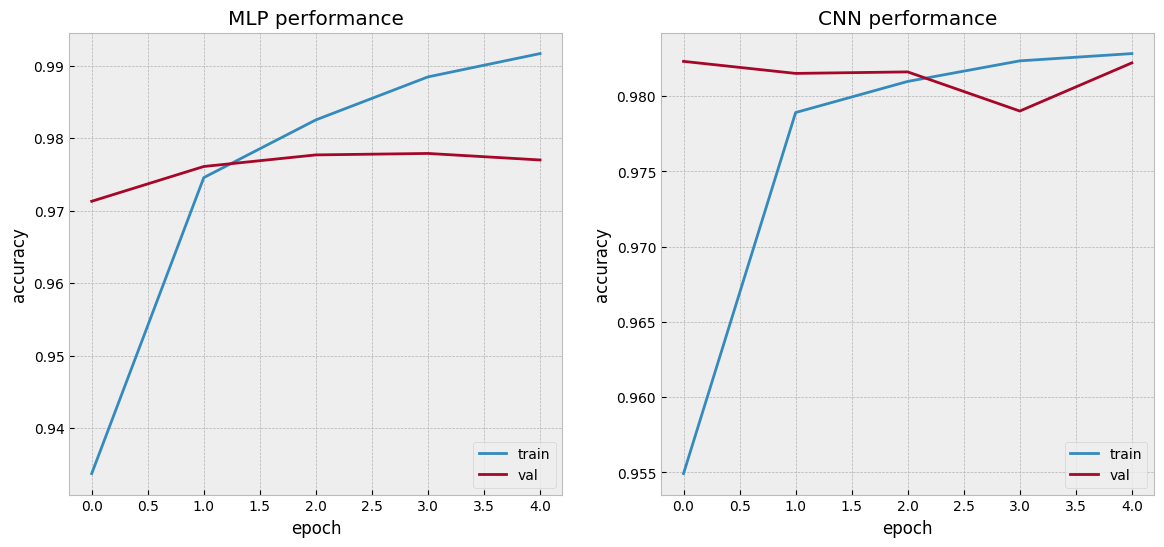

In [13]:
plt.style.use('bmh')
fig, ax = plt.subplots(figsize=(14, 6), ncols=2)

ax[0].plot(np.arange(5), train_acc_mlp, label='train')
ax[0].plot(np.arange(5), val_acc_mlp, label='val')
ax[0].set(xlabel='epoch', ylabel='accuracy', title='MLP performance')
ax[0].legend(loc='lower right')

ax[1].plot(np.arange(5), train_acc_cnn, label='train')
ax[1].plot(np.arange(5), val_acc_cnn, label='val')
ax[1].set(xlabel='epoch', ylabel='accuracy', title='CNN performance')
ax[1].legend(loc='lower right')

plt.show()